## ANN ON ADVERTISING.CSV

In [12]:
#loading

import pandas as pd
df=pd.read_csv("advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [13]:
#exploration basic

print(df.isnull().sum())
print(df.shape)
print(df.describe())
print(df.info())


#dropping + filling and all if reqd

# df=df.dropna() #drop null rows
# df=df.dropna(axis=1) #drop any null cols
# df=df.dropna(how='all') #drop only rows with all nulls
# df=df.fillna() #replace woth 0
# df=df.fillna(method='ffill') #forward filling

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
(200, 4)
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None


In [14]:
#select features and target

X=df.iloc[:,:-1]
y=df.iloc[:, -1]

In [15]:
#train test split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
#normalization

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [20]:
#building ann model + compile + train

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#input has 3 features -> output is 1 value
model=Sequential([
    Dense(8, activation='relu', input_shape=(3,)),
    Dense(1)  #regression output
])

#adam is efficient, mse is for regression loss, mae is eval metric
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=['mae'])

model.fit(X_train, y_train, epochs=200, validation_split=0.2)  #train for 50 iterations

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 242.7071 - mae: 14.7679 - val_loss: 221.1560 - val_mae: 13.9763
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 232.6210 - mae: 14.4362 - val_loss: 212.2073 - val_mae: 13.6547
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 221.9663 - mae: 14.0777 - val_loss: 203.0368 - val_mae: 13.3179
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 211.7334 - mae: 13.7161 - val_loss: 193.5905 - val_mae: 12.9635
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 201.1868 - mae: 13.3327 - val_loss: 183.7970 - val_mae: 12.5859
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 189.7596 - mae: 12.9131 - val_loss: 173.7854 - val_mae: 12.1911
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 178.1169 - mae: 12.4820 - val_loss: 163.4117 - val_mae: 11.7700
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 167.0090 - mae: 12.0302 - val_loss: 152.5877 - val_mae: 11.3239
Epoch 9/200
4/4 ━━━━━━━━

In [24]:
#predict and eval
    
y_pred=model.predict(X_test).flatten()
    
from sklearn.metrics import r2_score
print("ann r2 score:", r2_score(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
ann r2 score: 0.9184361504213573


## CMP WITH LINEAR REG & RANDOM FOREST

In [22]:
#linear reg

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train, y_train)

print("lr r2 score:", lr.score(X_test, y_test))

lr r2 score: 0.9059011844150826


In [23]:
#random forest

from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor()
rf.fit(X_train, y_train)
print("rf r2 score:", rf.score(X_test, y_test))

rf r2 score: 0.9537811995365861


## EVAL VIZ

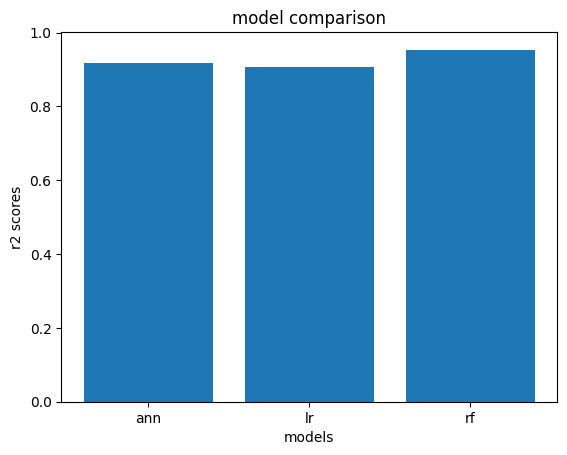

In [26]:
import matplotlib.pyplot as plt

ann_score=r2_score(y_test, y_pred)
lr_score=lr.score(X_test, y_test)
rf_score=rf.score(X_test, y_test)

models=["ann", "lr", "rf"]
scores=[ann_score, lr_score, rf_score]

plt.bar(models, scores)
plt.title("model comparison")
plt.xlabel("models")
plt.ylabel("r2 scores")
plt.show()

In [30]:
from sklearn.metrics import r2_score
r2_score?

Signature:
r2_score(
    y_true,
    y_pred,
    *,
    sample_weight=None,
    multioutput='uniform_average',
    force_finite=True,
)
Docstring:
:math:`R^2` (coefficient of determination) regression score function.

Best possible score is 1.0 and it can be negative (because the
model can be arbitrarily worse). In the general case when the true y is
non-constant, a constant model that always predicts the average y
disregarding the input features would get a :math:`R^2` score of 0.0.

In the particular case when ``y_true`` is constant, the :math:`R^2` score
is not finite: it is either ``NaN`` (perfect predictions) or ``-Inf``
(imperfect predictions). To prevent such non-finite numbers to pollute
higher-level experiments such as a grid search cross-validation, by default
these cases are replaced with 1.0 (perfect predictions) or 0.0 (imperfect
predictions) respectively. You can set ``force_finite`` to ``False`` to
prevent this fix from happening.

Note: when the prediction residuals hav